In [1]:
#8. setup environment
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Bidirectional
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
#9. load dataset
df = pd.read_csv("/content/drive/MyDrive/Job_3_Resource_sentiment.csv")

In [5]:
#9. inspect dataset
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [6]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [7]:
df.rename(columns={'Positive': 'sentiment'}, inplace=True)
df.rename(columns={'im getting on borderlands and i will murder you all ,': 'text'}, inplace=True)

In [8]:
df.columns

Index(['2401', 'Borderlands', 'sentiment', 'text'], dtype='object')

In [9]:
df = df[['text', 'sentiment']]

In [12]:
df.sample(5)

,text,sentiment
9396,Stress-test Savostore by shipping very delicat...,Positive
74635,Love EVERYTHING about it.,Positive
31064,"Me, when I realize you will die faster cause y...",Irrelevant
50152,FM20: loaded. Television: open. Oxford Satelli...,Positive
288,"Modern Warfare for $38, Borderlands 3 for $20 ...",Neutral


In [13]:
df.shape

(74681, 2)

In [14]:
df.isnull().sum()

,0
text,686
sentiment,0


In [15]:
print(df['sentiment'].value_counts())

sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [16]:
#10. Data cleaning
df.dropna(inplace=True)

In [17]:
df.isnull().sum()

,0
text,0
sentiment,0


In [18]:
# Convert text to string
df['text'] = df['text'].astype(str)

In [19]:
df['text']

,text
0,I am coming to the borders and I will kill you...
1,im getting on borderlands and i will kill you ...
2,im coming on borderlands and i will murder you...
3,im getting on borderlands 2 and i will murder ...
4,im getting into borderlands and i can murder y...
...,...
74676,Just realized that the Windows partition of my...
74677,Just realized that my Mac window partition is ...
74678,Just realized the windows partition of my Mac ...
74679,Just realized between the windows partition of...


In [21]:
#10. prepare the data
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

In [22]:
df['text']

,text
0,i am coming to the borders and i will kill you...
1,im getting on borderlands and i will kill you all
2,im coming on borderlands and i will murder you...
3,im getting on borderlands and i will murder y...
4,im getting into borderlands and i can murder y...
...,...
74676,just realized that the windows partition of my...
74677,just realized that my mac window partition is ...
74678,just realized the windows partition of my mac ...
74679,just realized between the windows partition of...


In [23]:
encoder = LabelEncoder()
df['sentiment_encoded'] = encoder.fit_transform(df['sentiment'])

print("Label mapping:")
for i, c in enumerate(encoder.classes_):
    print(i, "->", c)

Label mapping:
0 -> Irrelevant
1 -> Negative
2 -> Neutral
3 -> Positive


In [24]:
#11. tokenization and Padding
max_words = 20000
max_length = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

X = pad_sequences(
    tokenizer.texts_to_sequences(df['text']),
    maxlen=max_length,
    padding='post'
)

y = df['sentiment_encoded'].values

In [25]:
y

array([3, 3, 3, ..., 3, 3, 3])

In [26]:
#12. slit dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (51796, 100)
Validation: (11099, 100)
Test: (11100, 100)


In [27]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)


Class Weights: {0: np.float64(1.4368619618286729), 1: np.float64(0.8274121405750798), 2: np.float64(1.0215367623856106), 3: np.float64(0.8956287176649605)}


In [28]:
#13. design the DL(LSTM)
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(max_words, 128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,332 (10.14 MB)

 Trainable params: 2,659,332 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
#14. compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
#14. train model
early = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early],
    class_weight=class_weights_dict
)

Epoch 1/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.6385 - loss: 0.9078 - val_accuracy: 0.7482 - val_loss: 0.6567
Epoch 2/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.8335 - loss: 0.4582 - val_accuracy: 0.8237 - val_loss: 0.4732
Epoch 3/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.8851 - loss: 0.3117 - val_accuracy: 0.8460 - val_loss: 0.4382
Epoch 4/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.9093 - loss: 0.2419 - val_accuracy: 0.8498 - val_loss: 0.4470
Epoch 5/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.9239 - loss: 0.2019 - val_accuracy: 0.8613 - val_loss: 0.4319
Epoch 6/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9341 - loss: 0.1716 - val_accuracy: 0.8612 - val_loss: 0.4518
Epoch 7/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9403 - loss: 0.1554 - val_accuracy: 0.8660 - val_loss: 0.4584
Epoch 8/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9465 -

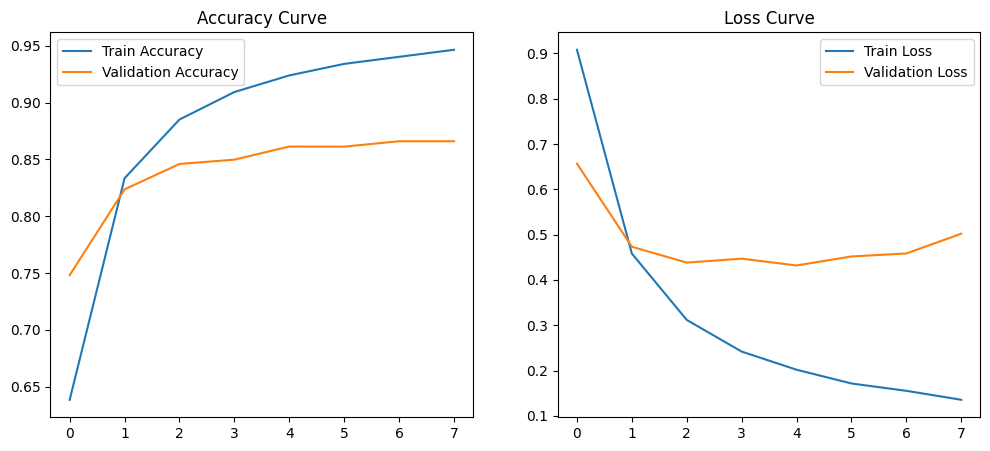

In [31]:
#16. visualize model performance
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()

In [32]:
#17. detect overfitting or underfitting
if history.history['accuracy'][-1] > history.history['val_accuracy'][-1]:
    print(" Possible Overfitting detected")
else:
    print(" Model is generalizing well")

 Possible Overfitting detected


In [33]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Accuracy: 0.8652252252252253
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1932
           1       0.88      0.89      0.89      3354
           2       0.87      0.85      0.86      2716
           3       0.85      0.88      0.87      3098

    accuracy                           0.87     11100
   macro avg       0.86      0.86      0.86     11100
weighted avg       0.87      0.87      0.87     11100



In [34]:
#18. save the model
model.save("sentiment_analysis_model.keras")
print(" Model saved successfully")

 Model saved successfully
